In [2]:
from nltk import word_tokenize
from nltk.corpus import stopwords
stops = stopwords.words('russian')
from nltk import sent_tokenize
import string
from collections import Counter

In [3]:
def text_metrics(text, sample_size = 10000):
    tokens = word_tokenize(text, language='russian')
    sent = sent_tokenize(text, language = 'russian')
    punkt = string.punctuation + '""–...'
    clean_tokens = [t for t in tokens if t not in punkt]
    clean_words = [word for word in tokens if word not in stops]
    clean_tokens_lowered = [t.lower() for t in clean_tokens]
    sample = clean_tokens_lowered[:sample_size]
    counted_tokens = Counter(sample)
    return {        
        'Средняя длина всех слов': sum(len(t) for t in sample)/len(sample),
        "Средняя длина слов без стоп-слов": sum(len(t) for t in clean_words)/len(clean_words),
        "Средняя длина предложений": len(sample)/len(sent),
        "TTR": len(set(sample)) / len(sample),
        "hapax": len([x for x in counted_tokens.values() if x == 1]),
        'word_count': len(clean_tokens_lowered)
        }

In [4]:
import pandas as pd
import os
folder = r"C:\Users\yuraz\Downloads\texts-20260705T081829Z-3-001\texts"
files = os.listdir(folder)
results = []
for filename in files:
    path = os.path.join(folder, filename)
    with open(path, 'r', encoding='utf-8') as file:
        text = file.read()
    metrics = text_metrics(text)
    metrics['Название файла'] = filename
    results.append(metrics)
df_metrics = pd.DataFrame(results)
df_metrics.head()

,Средняя длина всех слов,Средняя длина слов без стоп-слов,Средняя длина предложений,TTR,hapax,word_count,Название файла
0,4.9939,4.953315,2.499375,0.3790,2709,63313,abramovich_v_chernyj_stav_1917.txt
1,5.2919,4.714606,0.564621,0.4038,3050,196096,afanasev-chuzhbinskij_a_peterburgskie_igroki_1...
2,5.4123,4.948876,2.143623,0.4053,2968,61736,afanasev-chuzhbinskij_a_sosedka_1854.txt
3,4.7416,4.698284,0.766284,0.3344,2354,167363,akhsharumov_n_chuzhoe_imya_1861.txt
4,4.7078,4.376206,1.792436,0.3490,2559,69180,akhsharumov_n_konzy_v_vodu_1872.txt


In [5]:
df_metrics.shape

(538, 7)

In [7]:
df1 = pd.read_csv(r"C:\Users\yuraz\Downloads\russian_novels_metadata_char.csv")
df1

,author,title,subtitle,year,author_gender,pseudonym,genre,general_genre,genre1,genre2,...,char_эмигранты,char_придворная_знать,char_семейная_пара,char_рыцари,char_графы,char_слуги,char_врачи,char_ученые,char_types_count,has_char_info
0,"Эмин, Федор Александрович","Награждённая постоянность, или Приключения Лиз...",Сочинения Федора Эмина,1763,мужской,0,любовный,любовный,NaN,NaN,...,0,0,0,0,0,0,0,0,1,True
1,"Эмин, Федор Александрович","Непостоянная фортуна, или Похождения Мирамонда",NaN,1763,мужской,0,авантюрный,приключенческий,NaN,NaN,...,0,0,0,0,0,0,0,0,1,True
2,"Эмин, Федор Александрович","Приключения Фемистокла и разные политические, ...",NaN,1763,мужской,0,исторический,исторический,NaN,NaN,...,0,0,0,0,0,0,0,0,1,True
3,"Чулков, Михаил Дмитриевич","Пересмешник, или Славенские сказки",NaN,1766,мужской,0,NaN,NaN,авантюрный,сатирический,...,0,0,0,0,0,0,0,0,1,True
4,"Эмин, Федор Александрович",Письма Эрнеста и Доравры,NaN,1766,мужской,0,"философский, любовный",философский,NaN,NaN,...,0,0,0,0,0,0,0,0,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023,"Соловьев, Всеволод Сергеевич",Русские крестоносцы,повесть,1917,мужской,0,"дворяне, военные",исторический,NaN,NaN,...,0,0,0,0,0,0,0,0,1,True
2024,"Сухотин, Павел Сергеевич",Перчатка,"Записки русского кота, найденные Павлом Сухотиным",1917,мужской,0,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,1,True
2025,"Тимковский, Николай Иванович",В дворянской берлоге,Роман,1917,мужской,0,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,1,True
2026,"Тыркова, Ариандна Владимировна",Добыча,Роман,1917,женский,0,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,1,True


In [9]:
df_full = df1.merge(df_metrics, left_on='file_name', right_on='Название файла')
df_full.shape

(529, 67)

In [10]:
df_full['word_count'].min()
df_full['word_count'].describe()
df_full.sort_values('word_count').head(15)

,author,title,subtitle,year,author_gender,pseudonym,genre,general_genre,genre1,genre2,...,char_ученые,char_types_count,has_char_info,Средняя длина всех слов,Средняя длина слов без стоп-слов,Средняя длина предложений,TTR,hapax,word_count,Название файла
269,"Пушкин, Александр Сергеевич",Роман на кавказских водах,роман,1881,мужской,0,"любовный, семейная хроника",любовный,любовный,светский,...,0,1,True,5.063140,4.790123,12.208333,0.621160,289,586,pushkin_a_roman_na_kavkazskikh_vodakh_1881.txt
63,"Пушкин, Александр Сергеевич",Русский пелам,роман,1841,мужской,0,авантюрно-психологический роман,приключенческий,авантюрный,социально-психологический,...,0,1,True,5.015464,5.240695,11.149425,0.626804,509,970,pushkin_a_russkij_pelam_1841.txt
23,"Погорельский, Антоний",Магнетизер,роман,1830,мужской,1,NaN,NaN,фантастический,психологический,...,0,1,True,5.291121,5.380979,15.732824,0.524988,827,2061,perovskij_a_magnetizer_1830.txt
59,"Лажечников, Иван Иванович",Колдун на Сухаревской башне,роман,1840,мужской,0,"исторический роман, чернокнижник",исторический,исторический,фантастический,...,0,1,True,5.166592,5.040678,15.809859,0.560802,987,2245,lazhechnikov_i_koldun_na_sukharevskoj_bashne_1...
476,"Богораз, Владимир Германович",Завоевание вселенной,NaN,1909,мужской,0,"научная фантастика, неоконченый роман",фантастический,фантастический,философский,...,0,1,True,5.031070,4.668579,7.485050,0.505548,880,2253,bogoraz_v_zavoevanie_vselennoj_1909.txt
7,"Неелова, Наталья Алексеевна","Лейнард и Термилия, или Злосчастная судьба дау...",Сочинение девицы Н. Н.; Иждивением Н. Новикова...,1784,женский,0,сентиментальная повесть,любовный,сентиментальный,любовный,...,0,0,False,5.110114,5.226431,17.664634,0.412496,821,2897,neelova_n_lejnard_i_termiliya_ili_zloschastnay...
49,"Пушкин, Александр Сергеевич",Рославлев,NaN,1836,мужской,0,"исторический, социально-психологический",исторический,исторический,социально-психологический,...,0,1,True,5.236705,5.271099,13.783898,0.507839,1296,3253,pushkin_a_roslavlev_1836.txt
406,"Потапенко, Игнатий Николаевич",Слово и дело,Отрывок из воспоминаний,1898,мужской,0,социально-психологический,социальный,социально-психологический,идеологический,...,0,1,True,4.819270,4.714188,12.205993,0.448604,1108,3259,potapenko_i_slovo_i_delo_1898.txt
52,"Войт, Владимир Карлович",Битва с пиратами,Отрывок из морского романа,1838,мужской,0,приключенческий,приключенческий,приключенческий,авантюрный,...,0,2,True,5.223868,5.111407,14.086614,0.500838,1388,3578,vojt_v_bitva_s_piratami_1838.txt
9,"Зиновьев, Дмитрий Николаевич","Торжествующая добродетель, или Жизнь и приключ...","Истинная повесть, в восточных странах происход...",1789,мужской,0,авантюрный,приключенческий,авантюрный,нравоучительный,...,0,1,True,5.546429,5.910115,29.614865,0.502624,1728,4383,zinovev_d_torzhestvuyushaya_dobrodetel_ili_zhi...


In [42]:
df_full.groupby('canon')['TTR'].mean()

canon
0    0.400041
1    0.398860
Name: TTR, dtype: float64

In [11]:
df_full = df_full.rename(columns={
    'Средняя длина всех слов': "word_len_all",
    'Средняя длина слов без стоп-слов': 'word_len',
    "Средняя длина предложений": 'sent_len',
})

In [12]:
df_full.groupby('canon')['hapax'].mean()

canon
0    2890.901747
1    2783.605634
Name: hapax, dtype: float64

In [13]:
df_full.groupby('canon')['sent_len'].mean()

canon
0    3.265810
1    2.853354
Name: sent_len, dtype: float64

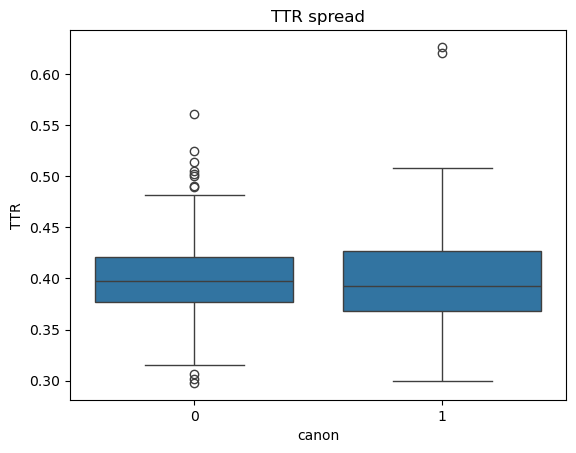

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df_full, x='canon', y='TTR')
plt.title("TTR spread")
plt.xlabel('canon')
plt.ylabel('TTR')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

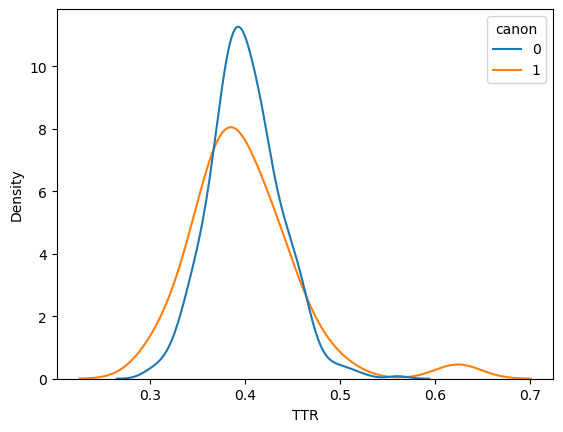

In [33]:
sns.kdeplot(data=df_full, x='TTR', hue='canon', common_norm=False) # Форма распределение независимо от размера группы
plt.show

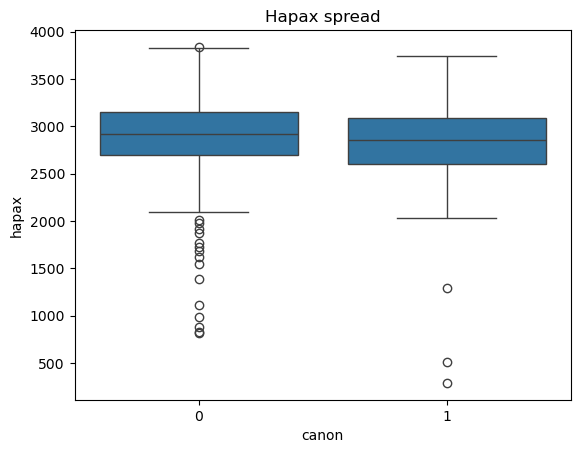

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df_full, x='canon', y='hapax')
plt.title("Hapax spread")
plt.xlabel('canon')
plt.ylabel('hapax')
plt.show()

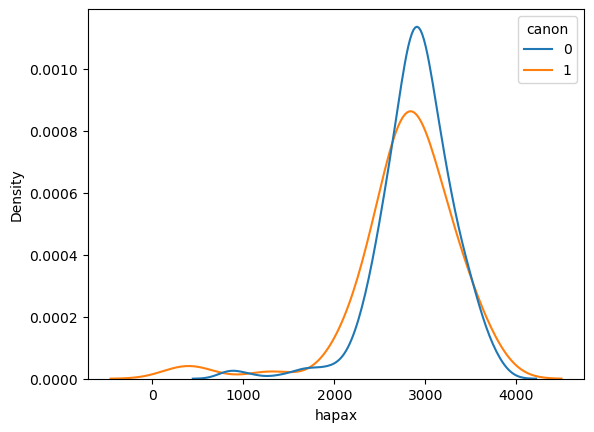

In [34]:
sns.kdeplot(data=df_full, x='hapax', hue='canon', common_norm=False)
plt.show()

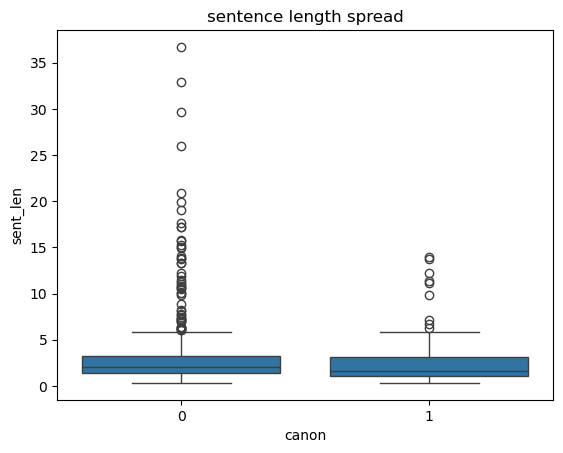

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df_full, x='canon', y='sent_len')
plt.title("sentence length spread")
plt.xlabel('canon')
plt.ylabel('sent_len')
plt.show()

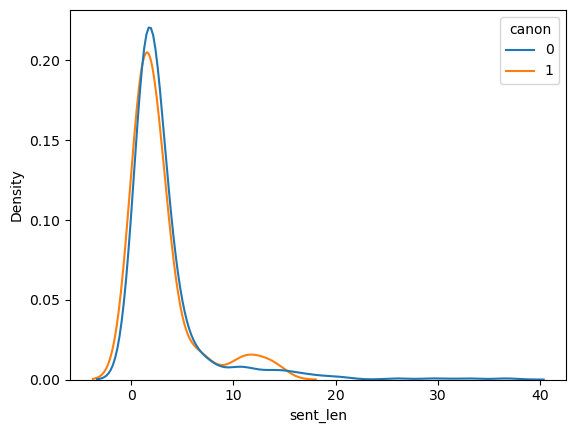

In [35]:
sns.kdeplot(data=df_full, x='sent_len', hue='canon', common_norm=False)
plt.show()

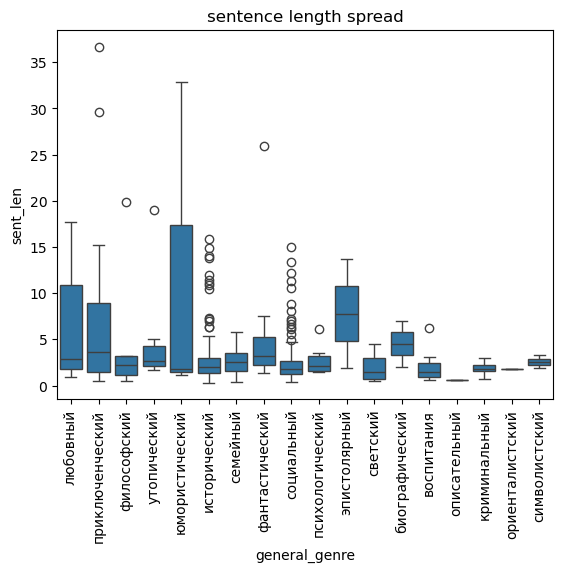

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df_full, x='general_genre', y='sent_len')
plt.title("sentence length spread")
plt.xlabel('general_genre')
plt.ylabel('sent_len')
plt.xticks(rotation=90)
plt.show()

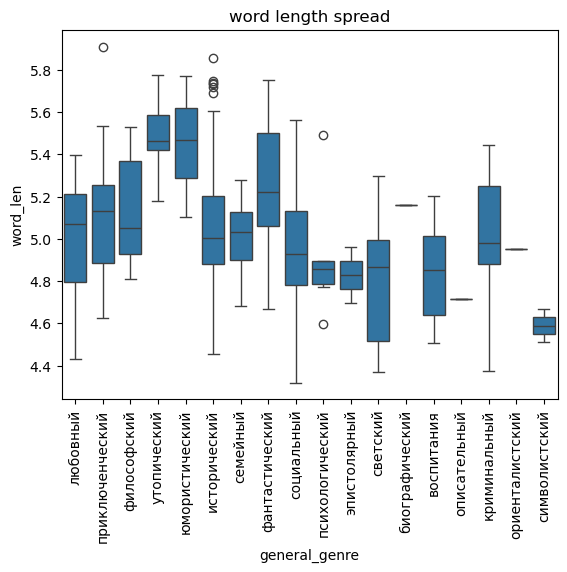

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df_full, x='general_genre', y='word_len')
plt.title("word length spread")
plt.xlabel('general_genre')
plt.ylabel('word_len')
plt.xticks(rotation=90)
plt.show()

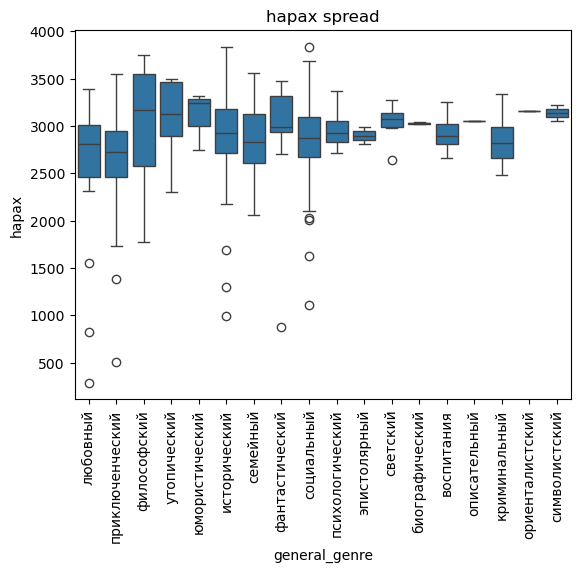

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df_full, x='general_genre', y='hapax')
plt.title("hapax spread")
plt.xlabel('general_genre')
plt.ylabel('hapax')
plt.xticks(rotation=90)
plt.show()

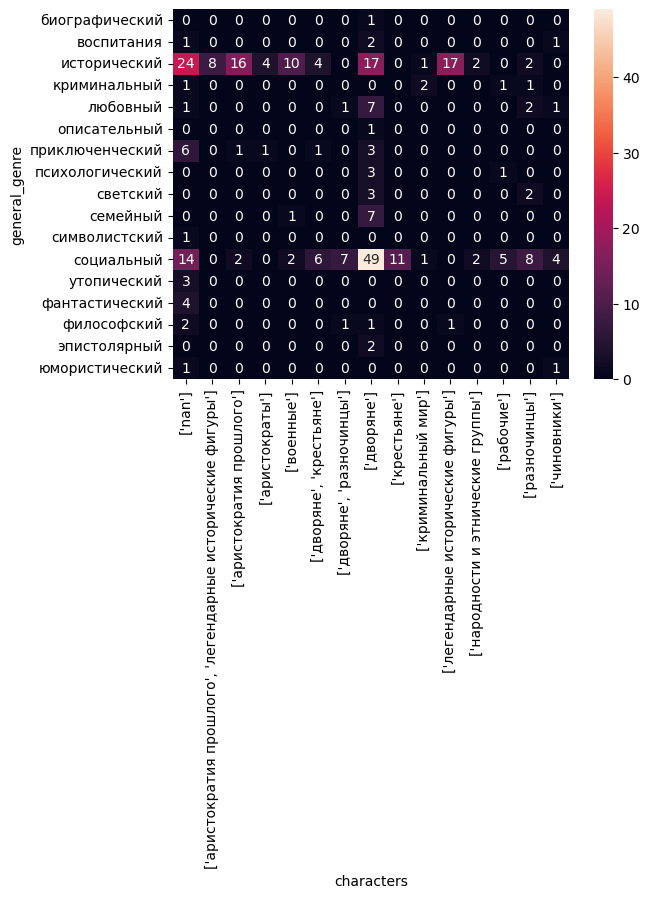

In [30]:
top = df_full['characters'].value_counts().head(15).index
df_top = df_full[df_full['characters'].isin(top)] # isin() - рассматривает сразу несколько топовых значений из таблицы
tab = pd.crosstab(df_top['general_genre'], df_top['characters'])
sns.heatmap(tab, annot=True, fmt='d') # annot - пишет число в каждой клетке fmt - числа целые
plt.xticks(rotation=90)
plt.show()

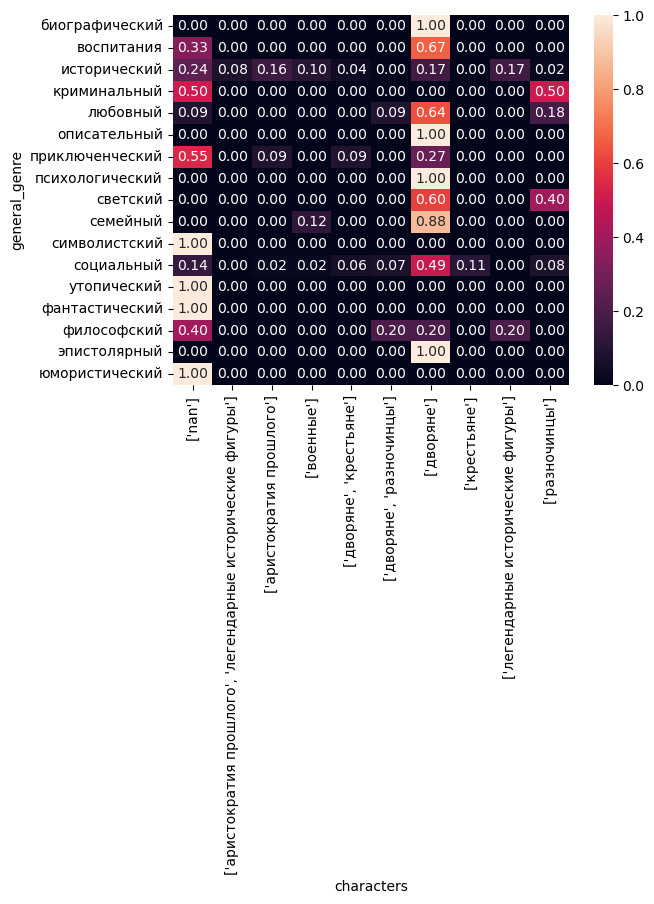

In [22]:
top = df_full['characters'].value_counts().head(10).index
df_top = df_full[df_full['characters'].isin(top)]
tab = pd.crosstab(df_top['general_genre'], df_top['characters'], normalize='index')
sns.heatmap(tab, annot=True, fmt='.2f') # annot - пишет число в каждой клетке fmt - числа целые
plt.xticks(rotation=90)
plt.show()

In [23]:
df['decade'] = df['year'] // 10*10

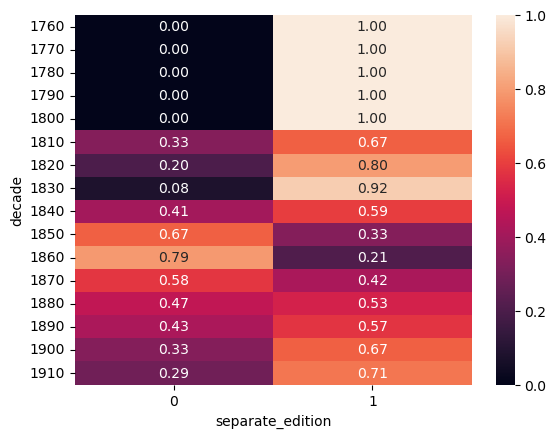

In [24]:
tab = pd.crosstab(df['decade'], df['separate_edition'], normalize = 'index')
sns.heatmap(tab, annot=True, fmt='.2f')
plt.show()

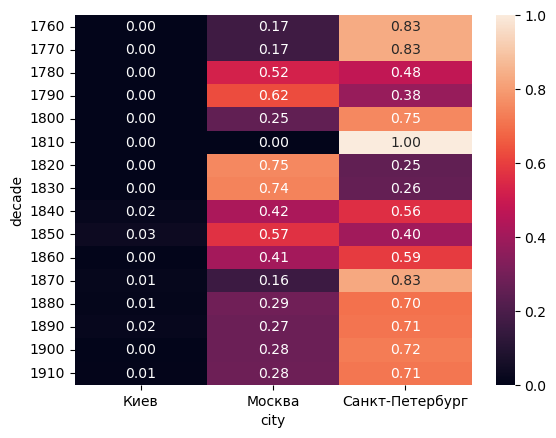

In [25]:
df['city'] = df['city'].replace('Петроград', "Санкт-Петербург")
city_top = df['city'].value_counts().head(3).index
df_top_city = df[df['city'].isin(city_top)]
tab = pd.crosstab(df_top_city['decade'], df_top_city['city'], normalize='index')
sns.heatmap(tab, annot=True, fmt='.2f')
plt.show()

In [26]:
df['city'].isna().sum()

np.int64(826)

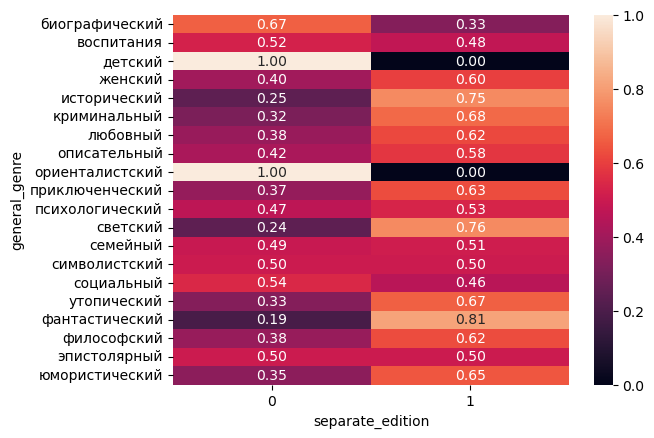

In [27]:
tab = pd.crosstab(df['general_genre'], df['separate_edition'], normalize = 'index')
sns.heatmap(tab, annot=True, fmt='.2f')
plt.show()

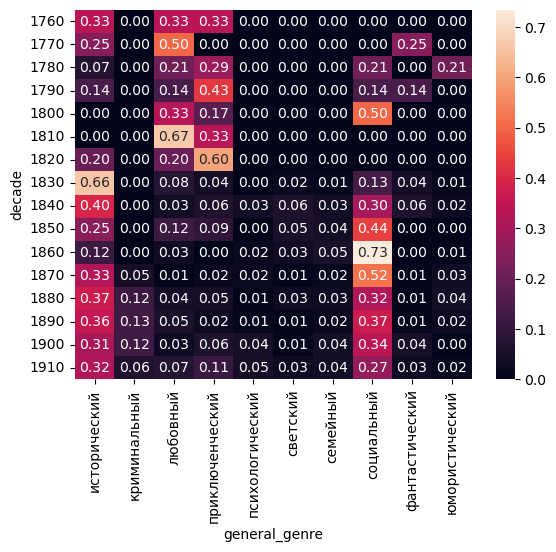

In [58]:
df['city'] = df['city'].replace('Петроград', "Санкт-Петербург")
gen_genre_top = df['general_genre'].value_counts().head(10).index
df_top_genre = df[df['general_genre'].isin(gen_genre_top)]
tab = pd.crosstab(df_top_genre['decade'], df_top_genre['general_genre'], normalize='index')
sns.heatmap(tab, annot=True, fmt='.2f')
plt.show()

In [28]:
df_full.groupby('general_genre')['sent_len'].mean().sort_values()

general_genre
описательный        0.564621
ориенталистский     1.808318
криминальный        1.822268
светский            1.976249
воспитания          2.140481
социальный          2.462922
символистский       2.561824
семейный            2.686447
исторический        2.695750
психологический     2.797892
биографический      4.528764
философский         4.835066
утопический         5.167333
фантастический      5.227773
любовный            6.286282
приключенческий     7.228432
эпистолярный        7.795981
юмористический     11.962843
Name: sent_len, dtype: float64

In [29]:
genres = ['genre1', 'genre2', 'genre3', 'genre4', 'genre5',]
df['genre_count'] = df[genres].notna().sum(axis=1)
df.groupby('canon')['genre_count'].mean()

canon
0    0.702925
1    3.025316
Name: genre_count, dtype: float64

In [61]:
df.groupby('decade')['genre_count'].mean()

decade
1760    0.666667
1770    1.166667
1780    1.142857
1790    0.647059
1800    1.000000
1810    3.666667
1820    1.500000
1830    0.639752
1840    0.881188
1850    0.844444
1860    1.368421
1870    1.281609
1880    0.757062
1890    0.576577
1900    0.766284
1910    0.612403
Name: genre_count, dtype: float64

In [62]:
df.to_csv("analysis.csv", index = False)

In [63]:
df_full.to_csv("analysis.csv", index = False)